<a href="https://colab.research.google.com/github/EAwoyemi110/Algoverse-all-experiements/blob/main/Scaled_Official_experiment_1_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Auth
from huggingface_hub import login
login()

In [ ]:
import os
import json
import random
import torch
import torch.nn.functional as F
from PIL import Image, ImageDraw
from transformers import AutoModel, AutoImageProcessor, PaliGemmaForConditionalGeneration

canvas_size = 224 #matches siglip-so400m-patch14-224's expected input, its vision tower resolu

object_size = 18 # was 40, needed to fit up to 32 non-overlapping objects
object_counts = [2, 4, 8, 16, 32]
n_images_per_count = 75

seed_base = 0
results_dir = "results/exp1"

shapes = ["circle", "triangle", "square"]
colors = ["blue", "red", "green", "yellow", "purple"]

In [ ]:
#load model
model_vit = AutoModel.from_pretrained("google/siglip-so400m-patch14-224")

model_vlm = PaliGemmaForConditionalGeneration.from_pretrained("google/paligemma2-3b-pt-224")

vision_tower = model_vlm.model.vision_tower

model_vit.eval()

model_vlm.eval()

processor = AutoImageProcessor.from_pretrained("google/siglip-so400m-patch14-224")

patch_size = model_vit.config.vision_config.patch_size

grid_size = canvas_size // patch_size

print(f"Patch size: {patch_size}, grid: {grid_size} x {grid_size}")


config.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


model.safetensors: reconstructing file:   0%|          |  0.00B / 3.51GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/727 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

Patch size: 14, grid: 16 x 16


In [ ]:
for name, module in model_vlm.named_modules():
  if "vision" in name.lower():
    print(name, "->", type(module).__name__)

model.vision_tower -> SiglipVisionModel
model.vision_tower.embeddings -> SiglipVisionEmbeddings
model.vision_tower.embeddings.patch_embedding -> Conv2d
model.vision_tower.embeddings.position_embedding -> Embedding
model.vision_tower.encoder -> SiglipEncoder
model.vision_tower.encoder.layers -> ModuleList
model.vision_tower.encoder.layers.0 -> SiglipEncoderLayer
model.vision_tower.encoder.layers.0.layer_norm1 -> LayerNorm
model.vision_tower.encoder.layers.0.self_attn -> SiglipAttention
model.vision_tower.encoder.layers.0.self_attn.k_proj -> Linear
model.vision_tower.encoder.layers.0.self_attn.v_proj -> Linear
model.vision_tower.encoder.layers.0.self_attn.q_proj -> Linear
model.vision_tower.encoder.layers.0.self_attn.out_proj -> Linear
model.vision_tower.encoder.layers.0.layer_norm2 -> LayerNorm
model.vision_tower.encoder.layers.0.mlp -> SiglipMLP
model.vision_tower.encoder.layers.0.mlp.activation_fn -> GELUTanh
model.vision_tower.encoder.layers.0.mlp.fc1 -> Linear
model.vision_tower.enc

In [ ]:
for name, module in list(model_vit.named_modules())[:30]:
  print(name, "->", type(module).__name__)

 -> SiglipModel
text_model -> SiglipTextModel
text_model.embeddings -> SiglipTextEmbeddings
text_model.embeddings.token_embedding -> Embedding
text_model.embeddings.position_embedding -> Embedding
text_model.encoder -> SiglipEncoder
text_model.encoder.layers -> ModuleList
text_model.encoder.layers.0 -> SiglipEncoderLayer
text_model.encoder.layers.0.layer_norm1 -> LayerNorm
text_model.encoder.layers.0.self_attn -> SiglipAttention
text_model.encoder.layers.0.self_attn.k_proj -> Linear
text_model.encoder.layers.0.self_attn.v_proj -> Linear
text_model.encoder.layers.0.self_attn.q_proj -> Linear
text_model.encoder.layers.0.self_attn.out_proj -> Linear
text_model.encoder.layers.0.layer_norm2 -> LayerNorm
text_model.encoder.layers.0.mlp -> SiglipMLP
text_model.encoder.layers.0.mlp.activation_fn -> GELUTanh
text_model.encoder.layers.0.mlp.fc1 -> Linear
text_model.encoder.layers.0.mlp.fc2 -> Linear
text_model.encoder.layers.1 -> SiglipEncoderLayer
text_model.encoder.layers.1.layer_norm1 -> Laye

In [ ]:
def is_block(module):
  #change module later based on actual class names printed above later
  return type(module).__name__ == "SiglipEncoderLayer"

activations_vit = {}
activations_vlm = {}

def get_hook(store, name):
  def hook(module, input, output):
    store[name] = output.detach().cpu()
  return hook

#now hook only the vision sub-module for condition1, not the whole SigLip
#it contains a text module which is not needed for condition 1
hooked_vit_names = []
for name, module in model_vit.vision_model.named_modules():
  if is_block(module):
    module.register_forward_hook(get_hook(activations_vit, name))
    hooked_vit_names.append(name)

hooked_vlm_names = []
for name, module in vision_tower.named_modules():
  if is_block(module):
    module.register_forward_hook(get_hook(activations_vlm, name))
    hooked_vlm_names.append(name)

print(f"Hooked {len(hooked_vit_names)} modules in model_vit")
print(f"Hooked {len(hooked_vlm_names)} modules in vision_tower")
#If either count is 0 or looks wrong (like way more than expected transformer layers)
#is_block() is matching the wrong thing, fix it before continuing
#both counts should match (same SigLip architecture family)


Hooked 27 modules in model_vit
Hooked 27 modules in vision_tower


In [ ]:
def boxes_overlap(box1, box2, padding=0):
  x1a, y1a, x2a, y2a = box1
  x1b, y1b, x2b, y2b = box2
  return not (x2a + padding < x1b or x1a > x2b + padding or y2a + padding < y1b or y1a > y2b + padding)

def make_image(num_objects, canvas_size=canvas_size, seed = 0, max_attempts=200):
  random.seed(seed)
  img = Image.new("RGB", (canvas_size, canvas_size), "white")
  draw = ImageDraw.Draw(img)
  objects = []

  for i in range(num_objects):
    placed = False
    for  attempt in range(max_attempts):
      x = random.randint(10, canvas_size - object_size - 10)
      y = random.randint(10, canvas_size - object_size - 10)
      bbox = [x, y, x + object_size, y + object_size]
      if not any(boxes_overlap(bbox, o["bbox"], padding=5) for o in objects):
        placed = True
        break

    if not placed:
      print(f"Warning: could only place {i} of {num_objects} objects (seed={seed})")
      break

    shape = random.choice(shapes)
    color = random.choice(colors)

    if shape == "circle":
      draw.ellipse(bbox, fill=color)
    elif shape == "square":
      draw.rectangle(bbox, fill=color)
    else:
      draw.polygon([(x, y + object_size), (x + object_size / 2, y), (x + object_size, y + object_size)], fill=color)


    objects.append({"shape": shape, "color": color, "bbox": bbox})

  return img, objects

def bbox_to_patch_indices(bbox, canvas_size=canvas_size, patch_size=patch_size):
  x1,y1,x2,y2 = bbox
  grid_size = canvas_size // patch_size
  px1, py1 = x1 // patch_size, y1 // patch_size
  px2, py2 = x2 // patch_size, y2 // patch_size

  indices = []
  for py in range(py1, min(py2 + 1, grid_size)):
    for px in range(px1, min(px2 + 1, grid_size)):
      indices.append(py * grid_size + px)
  return indices



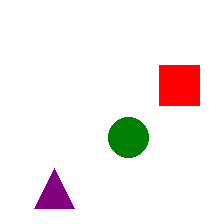

[{'shape': 'circle', 'color': 'green', 'bbox': [108, 117, 148, 157]}, {'shape': 'square', 'color': 'red', 'bbox': [159, 65, 199, 105]}, {'shape': 'triangle', 'color': 'purple', 'bbox': [34, 168, 74, 208]}]


In [ ]:
#test images
test_img, test_objects = make_image(num_objects=5, seed=0)
display(test_img)
print(test_objects)


In [ ]:
#run images through both conditions and diagnostic shape check

def run_through_both_conditions(img):
  activations_vit.clear()
  activations_vlm.clear()

  inputs = processor(images=img, return_tensors="pt")
  with torch.no_grad():
    #vision only
    _  = model_vit.vision_model(pixel_values=inputs["pixel_values"])
    _  = vision_tower(inputs["pixel_values"])

run_through_both_conditions(test_img)


#check activation
sample_layer = next(iter(activations_vit))
print(f"Sample '{sample_layer}' activation shape: {activations_vit[sample_layer].shape}")

Sample 'encoder.layers.0' activation shape: torch.Size([1, 256, 1152])


In [ ]:
#RDM computation
def compute_rdm(layer_activations, objects):
  object_vectors = []
  for obj in objects:
    idx = obj["patch_indices"]
    vec = layer_activations[idx].mean(dim=0)
    object_vectors.append(vec)

  object_vectors = torch.stack(object_vectors)

  normed = F.normalize(object_vectors, dim=1)
  similarity = normed @ normed.T
  rdm = 1 - similarity
  return rdm, similarity

In [ ]:
#Check layer 0 similarity should be low for 2-object image

sanity_img, sanity_objects = make_image(num_objects=2, seed=1)
for obj in sanity_objects:
  obj["patch_indices"] = bbox_to_patch_indices(obj["bbox"])

run_through_both_conditions(sanity_img)

first_layer_name = sorted(activations_vit.keys())[0]

layer0_acts = activations_vit[first_layer_name].squeeze(0)

rdm, sim = compute_rdm(layer0_acts, sanity_objects)

print(f"Layer 0 similarity betgween the 2 objects: {sim[0, 1].item():.4f}")

print("Expect this to be low, if it's near 1.0, stop and debug mapping")



Layer 0 similarity betgween the 2 objects: 0.5523
Expect this to be low, if it's near 1.0, stop and debug mapping


In [ ]:
#check mapping at layer 0
#two patches that are guaranteed pure background (no objects, top left corner far from any object)
bg_indices = [0,1]

bg_vec1 = layer0_acts[bg_indices[0]]
bg_vec2 = layer0_acts[bg_indices[1]]

bg_sim = F.cosine_similarity(bg_vec1.unsqueeze(0), bg_vec2.unsqueeze(0)).item()
print(f"Background-to-background similarity:  {bg_sim:.4f}")
print(f"Object-to-object similarity: {sim[0,1].item():.4f}")
#Goal: two patches of pure blank background are very similar
#and two patches of object are similar

Background-to-background similarity:  0.9518
Object-to-object similarity: 0.5523


In [ ]:
os.makedirs(results_dir, exist_ok=True)
results = []

for num_objects in object_counts:
  for img_idx in range (n_images_per_count):
    seed = seed_base + img_idx + num_objects * 10000 #scaled, varied so we are not reusing the same 10 random streams across every count
    img, objects = make_image(num_objects, seed=seed)

    if len(objects) < 2:
      continue

    for obj in objects:
      obj["patch_indices"] = bbox_to_patch_indices(obj["bbox"])

    run_through_both_conditions(img)

    for condition_name, activations in [
        ("vit_only", activations_vit),
        ("vlm_no_prompt", activations_vlm)

    ]:

      for layer_name, layer_acts in activations.items():
        acts = layer_acts.squeeze(0) #confirms cell 8

        rdm, sim = compute_rdm(acts, objects)
        n = len(objects)
        off_diag_mask = ~torch.eye(n, dtype=torch.bool)
        mean_sim = sim[off_diag_mask].mean().item()

        results.append({"condition": condition_name,
                        "layer": layer_name,
                        "num_objects": len(objects),
                        "image_id": img_idx,
                        "mean_similarity": mean_sim,
                        "rdm": rdm.tolist(),})

with open(os.path.join(results_dir, "raw_results.json"), "w") as f:
  json.dump(results, f)

print(f"Saved {len(results)} result rows to {results_dir}/raw_results.json")

In [ ]:
import pandas as pd
import json
import os

with open(os.path.join(results_dir, "raw_results.json"), "r") as f:
  results = json.load(f)


df = pd.DataFrame(results)
summary_df = df.drop(columns=["rdm"]) #drops full matrices for readability

print(f"Total rows: {len(summary_df)}")
print(summary_df.head(10))

In [ ]:
#stats
from scipy.stats import linregress
from statsmodels.stats.multitest import multipletests

layer_stats = []
for layer_name, group in summary_df[summary_df.condition=="vit_only"].groupby("layer"):
  slope, intercept, r, p, se = linregress(group["num_objects"], group["mean_similarity"])
  layer_stats.append({"layer": layer_name, "slope": slope, "p": p})
stats_df = pd.DataFrame(layer_stats)
stats_df["p_corrected"] = multipletests(stats_df["p"], method="fdr_bh")[1]

In [ ]:
table = (
    summary_df
    .groupby(["condition", "layer", "num_objects"])["mean_similarity"]
    .mean()
    .reset_index()
)

vit_pivot = table[table["condition"] == "vit_only"].pivot_table(
    index="layer", columns="num_objects", values="mean_similarity"
)

vit_pivot = vit_pivot.reindex(sorted(vit_pivot.index, key=lambda x: int(x.split(".")[-1])))
vit_pivot